In [1]:
# Quantitative Finance from First Principles
## Connecting Physics to Financial Modelling
### Oliver Chinn — BSc Physics, University of Lincoln

In [2]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scripts.fetch_data import get_volatility_params
from scripts.black_scholes import black_scholes, greeks
from scripts.monte_carlo import simulate_gbm
from scripts.portfolio_risk import (load_returns, value_at_risk,
                                    efficient_frontier, find_optimal_portfolio)

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})
params = get_volatility_params()

for ticker, p in params.items():
    print(f"  {ticker}: return={p['mu']*100:.1f}%, vol={p['sigma']*100:.1f}%, price=${p['last_price']:.2f}")

  AAPL: mu=0.219, sigma=0.280, S0=$332.17
  MSFT: mu=0.167, sigma=0.282, S0=$513.76
  NVDA: mu=0.633, sigma=0.519, S0=$235.39
  JPM: mu=0.192, sigma=0.244, S0=$330.90
  GOOGL: mu=0.242, sigma=0.322, S0=$341.75
  AAPL: return=21.9%, vol=28.0%, price=$332.17
  MSFT: return=16.7%, vol=28.2%, price=$513.76
  NVDA: return=63.3%, vol=51.9%, price=$235.39
  JPM: return=19.2%, vol=24.4%, price=$330.90
  GOOGL: return=24.2%, vol=32.2%, price=$341.75


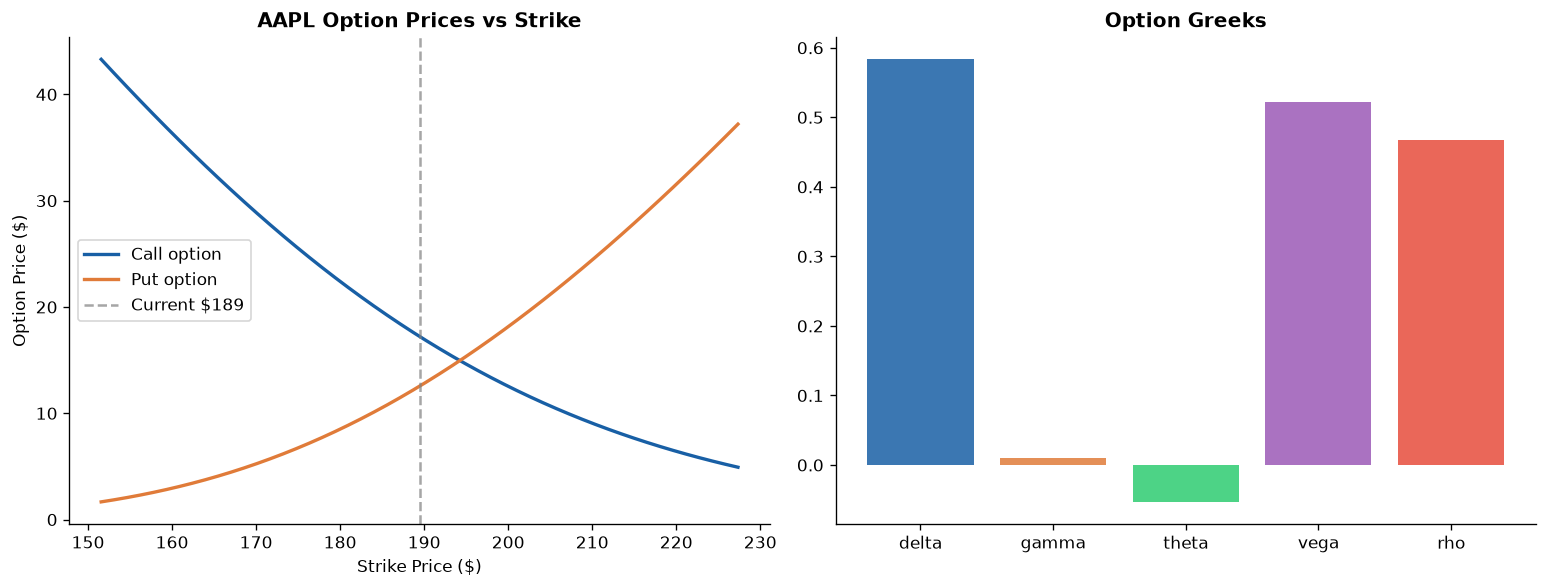

Greeks: {'delta': np.float64(0.5834), 'gamma': np.float64(0.01039), 'theta': np.float64(-0.053), 'vega': np.float64(0.5227), 'rho': np.float64(0.4678)}


In [3]:
S, K, T, r = 189.45, 190.0, 0.5, 0.05
sigma = params['AAPL']['sigma']

strikes = np.linspace(S * 0.8, S * 1.2, 50)
calls   = [black_scholes(S, K, T, r, sigma, 'call') for K in strikes]
puts    = [black_scholes(S, K, T, r, sigma, 'put')  for K in strikes]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(strikes, calls, '#185FA5', linewidth=2, label='Call option')
ax1.plot(strikes, puts,  '#E07B39', linewidth=2, label='Put option')
ax1.axvline(S, color='gray', linestyle='--', alpha=0.7, label=f'Current ${S:.0f}')
ax1.set_xlabel('Strike Price ($)')
ax1.set_ylabel('Option Price ($)')
ax1.set_title('AAPL Option Prices vs Strike', fontweight='bold')
ax1.legend()

g = greeks(S, K, T, r, sigma)
ax2.bar(list(g.keys()), list(g.values()),
        color=['#185FA5','#E07B39','#2ECC71','#9B59B6','#E74C3C'], alpha=0.85)
ax2.set_title('Option Greeks', fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/bs_options.png', bbox_inches='tight')
plt.show()
print(f"Greeks: {g}")

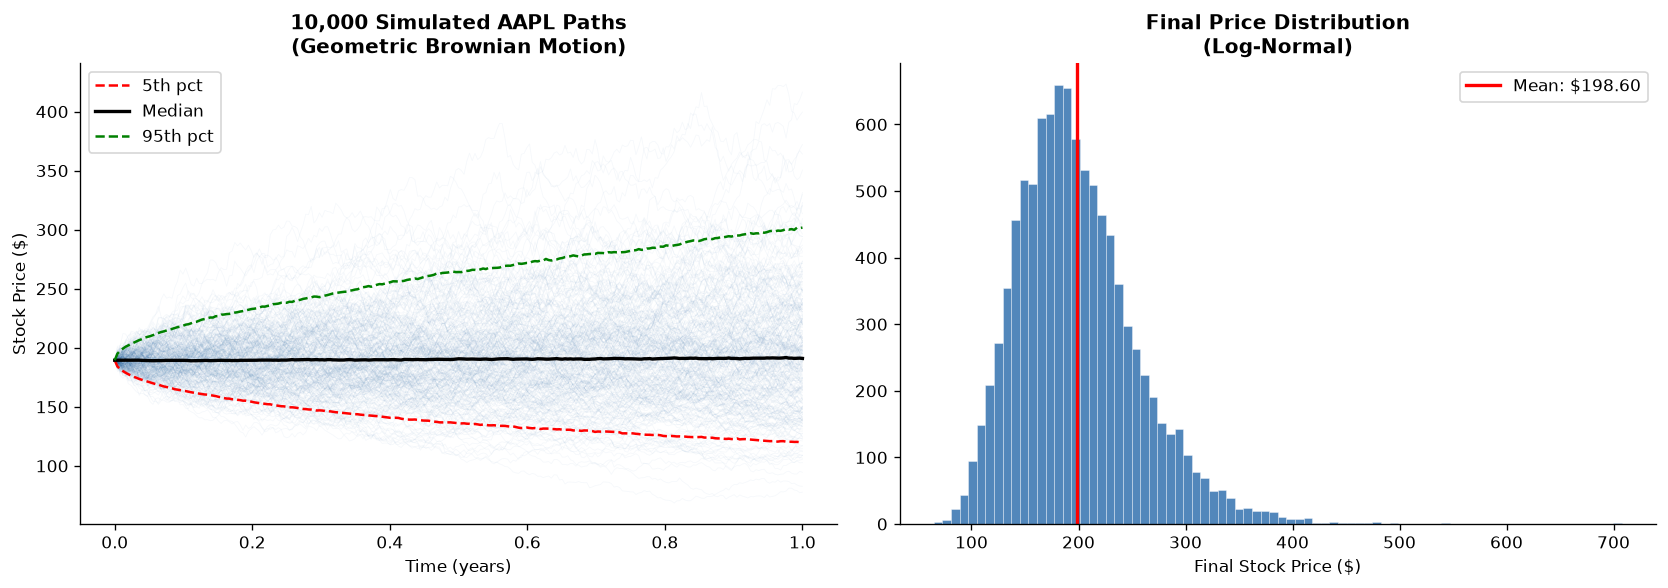

In [4]:
paths = simulate_gbm(S, mu=r, sigma=sigma, T=1.0, n_paths=10000)
t = np.linspace(0, 1, paths.shape[1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i in range(300):
    axes[0].plot(t, paths[i], alpha=0.04, color='#185FA5', linewidth=0.5)
axes[0].plot(t, np.percentile(paths, 5,  axis=0), 'r--', lw=1.5, label='5th pct')
axes[0].plot(t, np.percentile(paths, 50, axis=0), 'k-',  lw=2.0, label='Median')
axes[0].plot(t, np.percentile(paths, 95, axis=0), 'g--', lw=1.5, label='95th pct')
axes[0].set_title('10,000 Simulated AAPL Paths\n(Geometric Brownian Motion)', fontweight='bold')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Stock Price ($)')
axes[0].legend()
axes[1].hist(paths[:,-1], bins=80, color='#185FA5', alpha=0.75, edgecolor='white', lw=0.3)
axes[1].axvline(np.mean(paths[:,-1]), color='red', lw=2, label=f"Mean: ${np.mean(paths[:,-1]):.2f}")
axes[1].set_title('Final Price Distribution\n(Log-Normal)', fontweight='bold')
axes[1].set_xlabel('Final Stock Price ($)')
axes[1].legend()
plt.tight_layout()
plt.savefig('../docs/mc_paths.png', bbox_inches='tight')
plt.show()

VaR: On 95% of days, daily loss < 2.49%

Optimal Portfolio (Max Sharpe):
  AAPL: 4.1%
  MSFT: 0.0%
  NVDA: 64.1%
  JPM: 31.7%
  GOOGL: 0.0%
  Return: 47.60%  Vol: 37.14%  Sharpe: 1.147


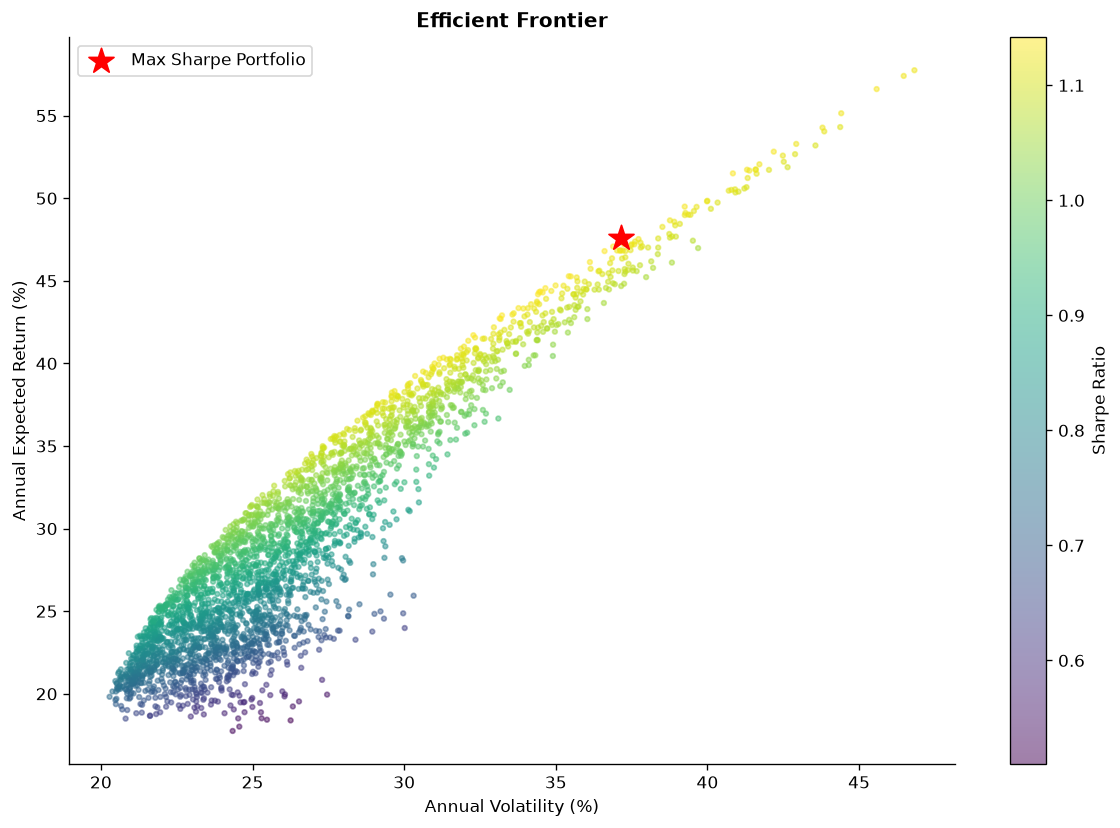

In [5]:
returns = load_returns()
equal_w = np.array([0.2]*5)
var_res = value_at_risk(returns, equal_w)
print(f"VaR: {var_res['interpretation']}")

ef_results, mean_ret, cov_mat = efficient_frontier(returns, n_portfolios=3000)
opt_w, opt_r, opt_v, opt_s   = find_optimal_portfolio(mean_ret, cov_mat)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(ef_results['vol']*100, ef_results['return']*100,
                c=ef_results['sharpe'], cmap='viridis', alpha=0.5, s=8)
plt.colorbar(sc, label='Sharpe Ratio')
ax.scatter(opt_v*100, opt_r*100, color='red', s=250, zorder=5,
           marker='*', label='Max Sharpe Portfolio')
ax.set_xlabel('Annual Volatility (%)')
ax.set_ylabel('Annual Expected Return (%)')
ax.set_title('Efficient Frontier', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../docs/efficient_frontier_nb.png', bbox_inches='tight')
plt.show()